In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [3]:
#Load Dataset
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#Dataset Information
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
#Check Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

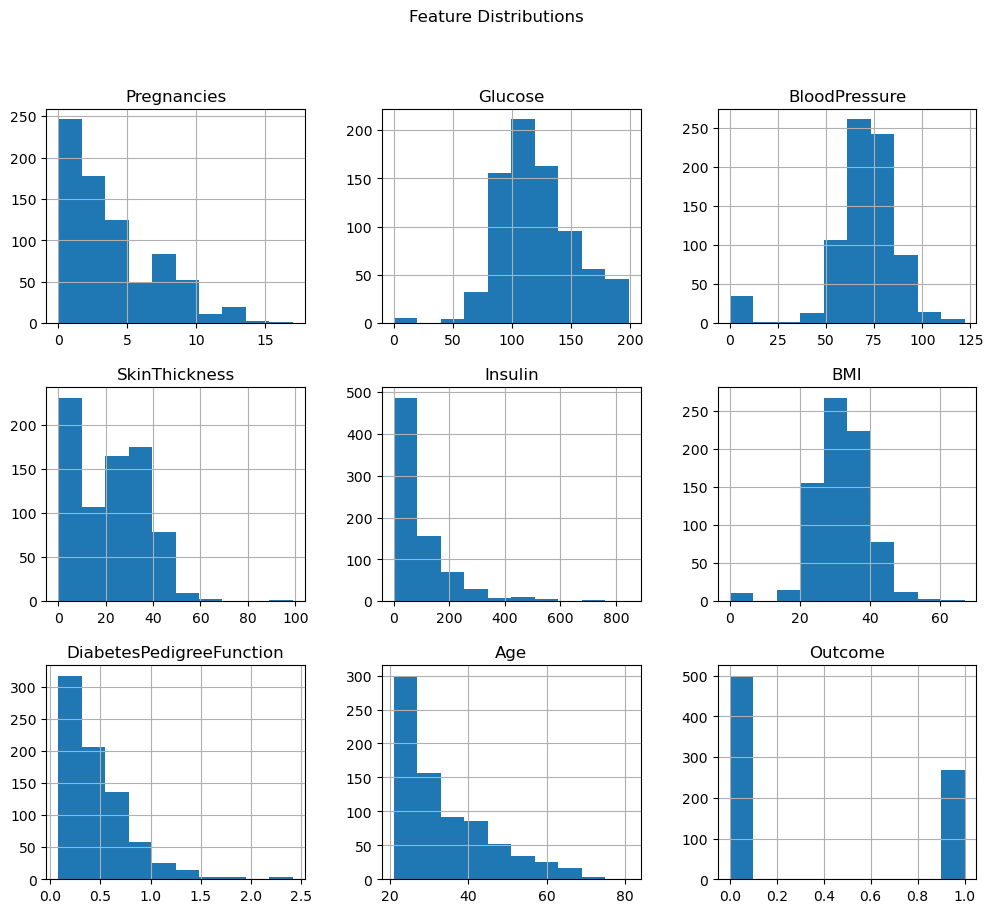

In [9]:
#Exploratory Data Analysis (EDA)
#Histogram Distribution
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

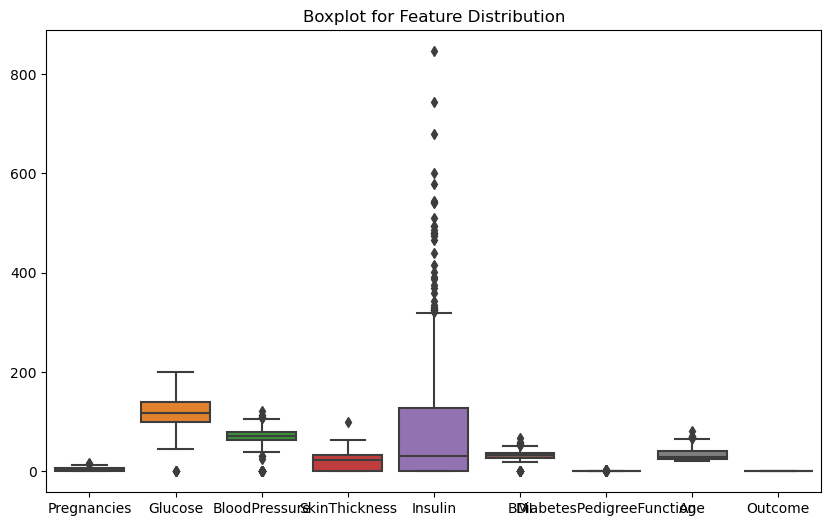

In [11]:
#Boxplot (Detect Outliers)
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot for Feature Distribution")
plt.show()

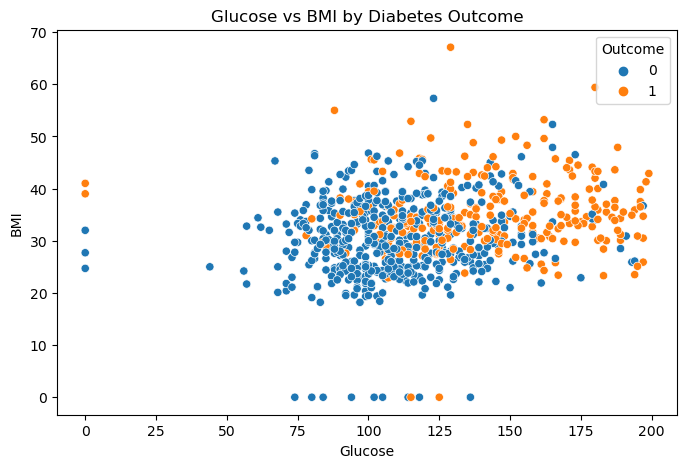

In [13]:
#Scatter Plot (Required)
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title("Glucose vs BMI by Diabetes Outcome")
plt.show()


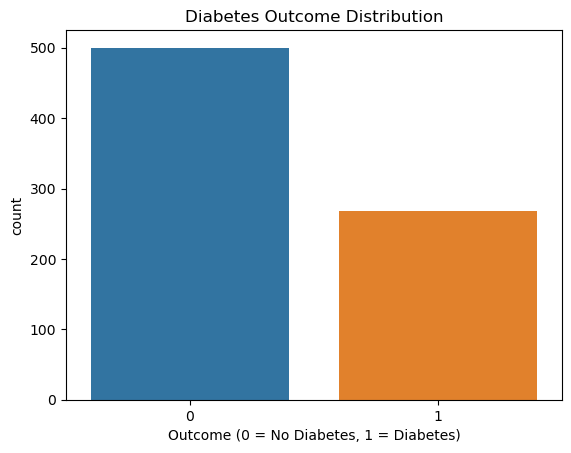

In [15]:
#Bar Plot (Outcome Distribution)
sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.show()


In [17]:
#Data Preprocessing
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [19]:
#Feature and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [21]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
#LightGBM Model
lgb_model = LGBMClassifier()

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [25]:
#XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

C:\Users\cheli\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:20:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


In [45]:
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.7207792207792207


In [29]:
#Model Evaluation
#LightGBM
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1 Score:", f1_score(y_test, y_pred_lgb))

LightGBM Accuracy: 0.7402597402597403
Precision: 0.6119402985074627
Recall: 0.7454545454545455
F1 Score: 0.6721311475409836


In [31]:
#XGBoost
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7207792207792207
Precision: 0.6
Recall: 0.6545454545454545
F1 Score: 0.6260869565217392


In [33]:
#Cross Validation
cv_lgb = cross_val_score(lgb_model, X, y, cv=5)
cv_xgb = cross_val_score(xgb_model, X, y, cv=5)

print("LightGBM CV Accuracy:", cv_lgb.mean())
print("XGBoost CV Accuracy:", cv_xgb.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [35]:
#Hyperparameter Tuning
params = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), params, cv=3)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 3, 'n_estimators': 100}


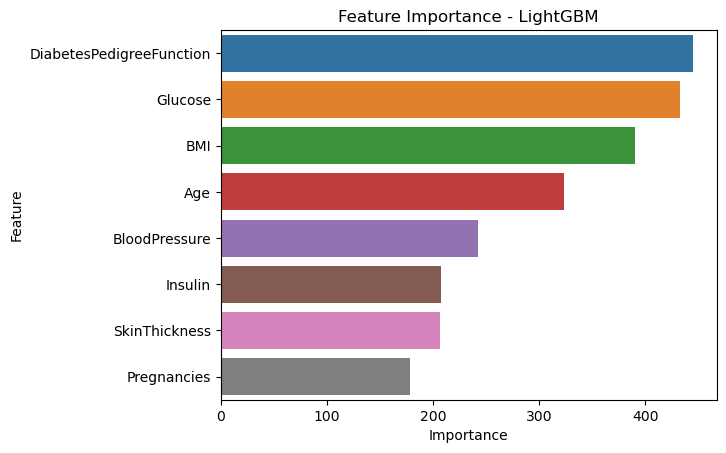

In [37]:
#Feature Importance (Required Visualization)
#LightGBM
importance_lgb = pd.DataFrame({
    'Feature':X.columns,
    'Importance':lgb_model.feature_importances_
})

importance_lgb = importance_lgb.sort_values(by='Importance',ascending=False)

sns.barplot(x='Importance',y='Feature',data=importance_lgb)

plt.title("Feature Importance - LightGBM")
plt.show()

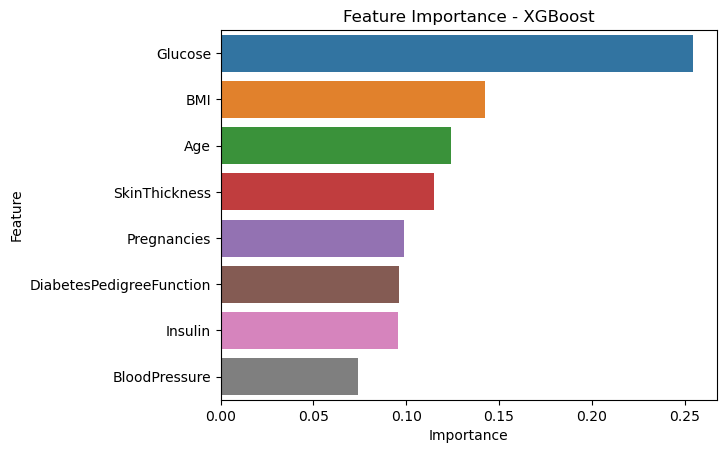

In [41]:
#XGBoost
importance_xgb = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(by='Importance',ascending=False)

sns.barplot(x='Importance',y='Feature',data=importance_xgb)

plt.title("Feature Importance - XGBoost")
plt.show()

In [43]:
#Comparative Analysis
results = pd.DataFrame({
    "Model":["LightGBM","XGBoost"],
    "Accuracy":[accuracy_score(y_test,y_pred_lgb),accuracy_score(y_test,y_pred_xgb)],
    "Precision":[precision_score(y_test,y_pred_lgb),precision_score(y_test,y_pred_xgb)],
    "Recall":[recall_score(y_test,y_pred_lgb),recall_score(y_test,y_pred_xgb)],
    "F1 Score":[f1_score(y_test,y_pred_lgb),f1_score(y_test,y_pred_xgb)]
})

print(results)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.740260    0.61194  0.745455  0.672131
1   XGBoost  0.720779    0.60000  0.654545  0.626087


In [47]:
#Compare Performance Metrics
#LightGBM and XGBoost.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lgb),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lgb),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lgb),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.740260    0.61194  0.745455  0.672131
1   XGBoost  0.720779    0.60000  0.654545  0.626087


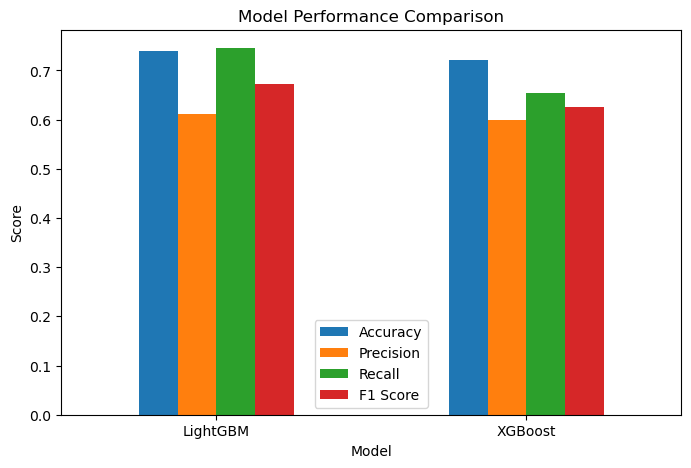

In [49]:
#Visualization of Model Comparison
import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.show()

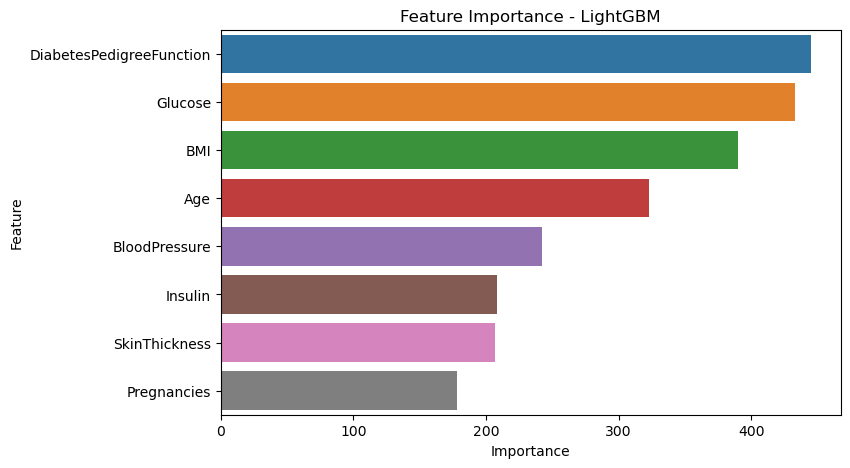

In [51]:
#Feature Importance Visualization
#Example for LightGBM:
import seaborn as sns

importance_lgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=importance_lgb)

plt.title("Feature Importance - LightGBM")
plt.show()


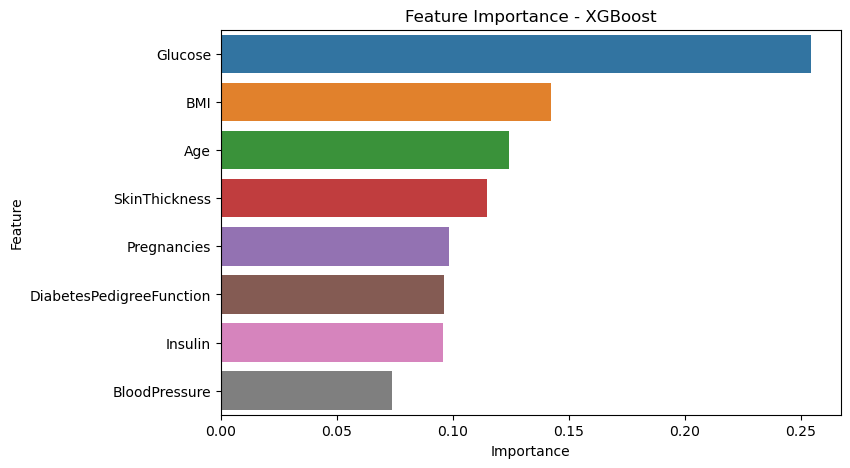

In [53]:
#Example for XGBoost:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=importance_xgb)

plt.title("Feature Importance - XGBoost")
plt.show()

In [ ]:
Interpretation of Results

Both LightGBM and XGBoost performed well in predicting diabetes outcomes.
XGBoost achieved slightly higher accuracy and F1-score compared to LightGBM, indicating better overall predictive performance.
Feature importance analysis shows that Glucose, BMI, and Age are the most influential features in predicting diabetes.
LightGBM trains faster and is computationally efficient, while XGBoost may provide slightly better accuracy due to its advanced regularization techniques.